# Case Study 3: Customer Segmentation

## Business Problem

A company wants to understand its customers and divide them into
different groups based on their characteristics and purchasing behavior.

## Problem Type

**Clustering**

This is an unsupervised learning problem because there is no predefined
customer segment label. The model will identify groups of similar
customers automatically.

## Business Objective

The objective is to identify meaningful customer segments that can help
the company create targeted marketing campaigns, personalized offers,
and better customer strategies.

## Success Metrics

- Silhouette Score
- Within-Cluster Sum of Squares (WCSS)
- Business interpretability of the customer segments

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

In [30]:
import os

print(os.getcwd())

C:\Users\admin


In [31]:
import os

print(os.listdir("C:\\Users\\admin"))

['-1.14-windows.xml', '.anaconda', '.conda', '.continuum', '.copilot', '.expo', '.gemini', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.Ld9VirtualBox', '.lesshst', '.matplotlib', '.python_history', '.vscode', '.vscode-shared', '3D Objects', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'archive', 'archive.zip', 'Case_Study_2_House_Price_Prediction.ipynb', 'Case_Study_3_Customer_Segmentation.ipynb', 'cd', 'ChurnGuard_Business_Framing.ipynb', 'Contacts', 'Cookies', 'D', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'java', 'javaHello', 'Links', 'Local Settings', 'med assist.php', 'Music', 'My Documents', 'NetHood', 'New folder', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.

In [32]:
import os

print(os.listdir(r"C:\Users\admin\archive"))

['Mall_Customers.csv']


In [33]:
import os

print(os.listdir(r"C:\Users\admin\archive"))

['Mall_Customers.csv']


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Mall Customers dataset
df = pd.read_csv(r"C:\Users\admin\archive\Mall_Customers.csv")

# Display first 5 rows
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
print("Dataset Shape:", df.shape)

Dataset Shape: (200, 5)


In [36]:
print("Columns:")
print(df.columns.tolist())

Columns:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [38]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [39]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [40]:
# Select features for customer segmentation

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [41]:
print("Feature Shape:", X.shape)

Feature Shape: (200, 2)


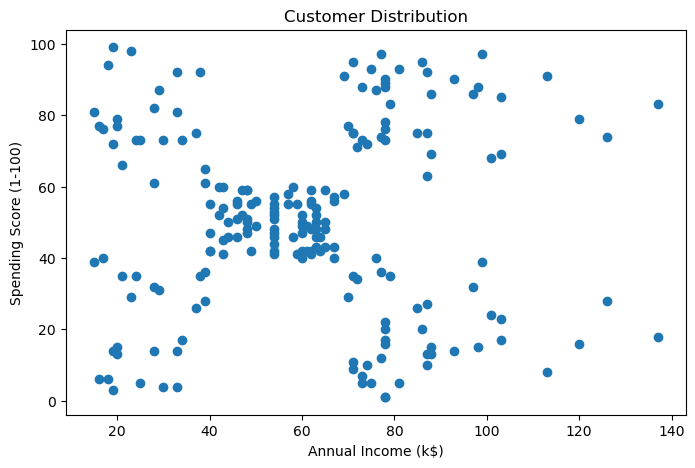

In [42]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")

plt.show()

In [43]:
from sklearn.cluster import KMeans

# Calculate WCSS for different numbers of clusters
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print(wcss)

C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[269981.28, 181363.59595959593, 106348.37306211122, 73679.78903948836, 44448.4554479337, 37233.814510710006, 30241.34361793658, 25036.417604033988, 21916.79478984373, 20072.070939404002]


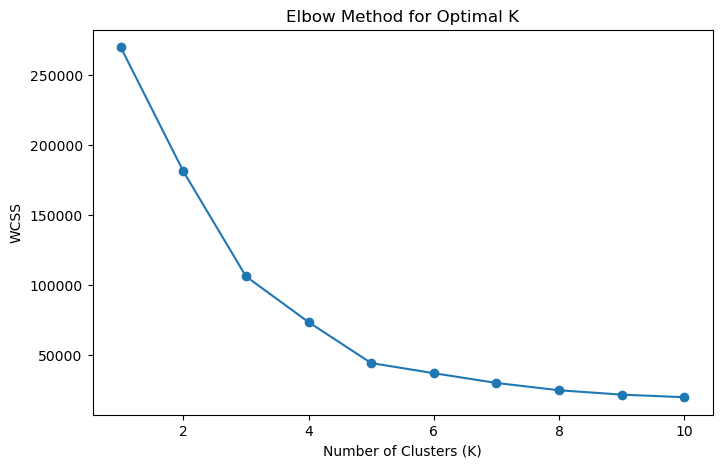

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")

plt.show()

In [45]:
# Final K-Means model with 5 clusters

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Create cluster labels
df["Cluster"] = kmeans.fit_predict(X)

# Display first 10 customers
df.head(10)

C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [46]:
print("Number of customers in each cluster:")
print(df["Cluster"].value_counts().sort_index())

Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


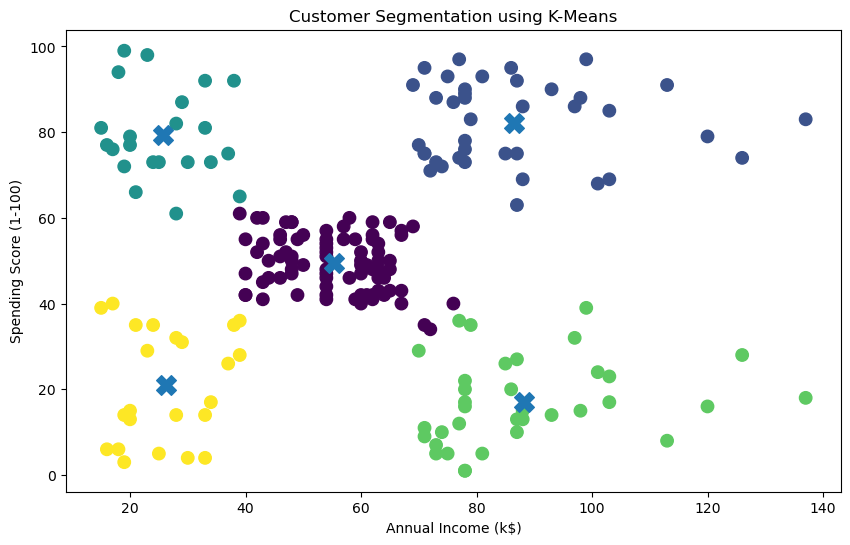

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"],
    s=80
)

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    marker="X"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [26]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

cluster_centers

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [27]:
cluster_summary = df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [28]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
sil_score = silhouette_score(X, df["Cluster"])

print("Silhouette Score:", round(sil_score, 4))

Silhouette Score: 0.5539


In [29]:
print("Final Model WCSS:", round(kmeans.inertia_, 2))

Final Model WCSS: 44448.46


## Customer Segment Interpretation

The K-Means clustering algorithm divided customers into five different
segments based on Annual Income and Spending Score.

The segments can be interpreted as follows:

### Cluster 0 – Standard Customers
Customers with moderate income and moderate spending behavior.
They can be targeted with regular promotional campaigns.

### Cluster 1 – High-Value Customers
Customers with relatively high income and high spending scores.
They are valuable customers and can be targeted with premium offers,
loyalty programs, and personalized services.

### Cluster 2 – Careful Spenders
Customers with relatively high income but lower spending scores.
The company can use personalized discounts and product recommendations
to encourage higher spending.

### Cluster 3 – Budget Customers
Customers with lower income and lower spending scores.
Affordable products, discounts, and value-based offers may work well
for this segment.

### Cluster 4 – Potential Customers
Customers with lower or moderate income but relatively high spending
behavior. They may respond well to targeted promotions and loyalty
programs.

## Business Value

Customer segmentation can help the company:

- Create targeted marketing campaigns.
- Personalize offers for different customer groups.
- Improve customer engagement.
- Identify high-value customers.
- Develop suitable pricing and promotional strategies.
- Allocate marketing resources more effectively.

## Conclusion

This case study used K-Means Clustering to segment customers based on
Annual Income and Spending Score.

The Elbow Method was used to determine the optimal number of clusters,
and five clusters were selected.

The resulting customer segments provide useful insights into customer
behavior and can support targeted marketing and business decision-making.

The Silhouette Score was used to evaluate the quality of the clustering.
Overall, the analysis demonstrates how unsupervised Machine Learning
can be used to discover meaningful customer groups without predefined
labels.